In [1]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
import os

# 读取清洗后的完整数据
df = pd.read_csv("data/student_combined_cleaned.csv")

# 特征与目标
X = df.drop(columns=["G3"])
y = df["G3"]

# 对分类特征独热编码
X = pd.get_dummies(X)

# 划分 70% 训练集
X_train, X_eval, y_train, y_eval = train_test_split(X, y, test_size=0.3, random_state=42)

# 保存训练集数据
train_df = pd.concat([X_train, y_train], axis=1)
train_df.to_csv("E:/TPU_Work/jidian_shujufenxi/tpu_8EM41_ML_course/10/data/raw/xgboost_train_data_full.csv", index=False)

# 训练 XGBoost 模型
model = xgb.XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

# 保存模型
model.save_model("E:/TPU_Work/jidian_shujufenxi/tpu_8EM41_ML_course/models/xgboost_model_full.json")

print("XGBoost 模型训练完成，训练集数据与模型已保存。")

XGBoost 模型训练完成，训练集数据与模型已保存。


XGBoost 评估结果：
MSE: 2.271653413772583
R² : 0.8485520482063293


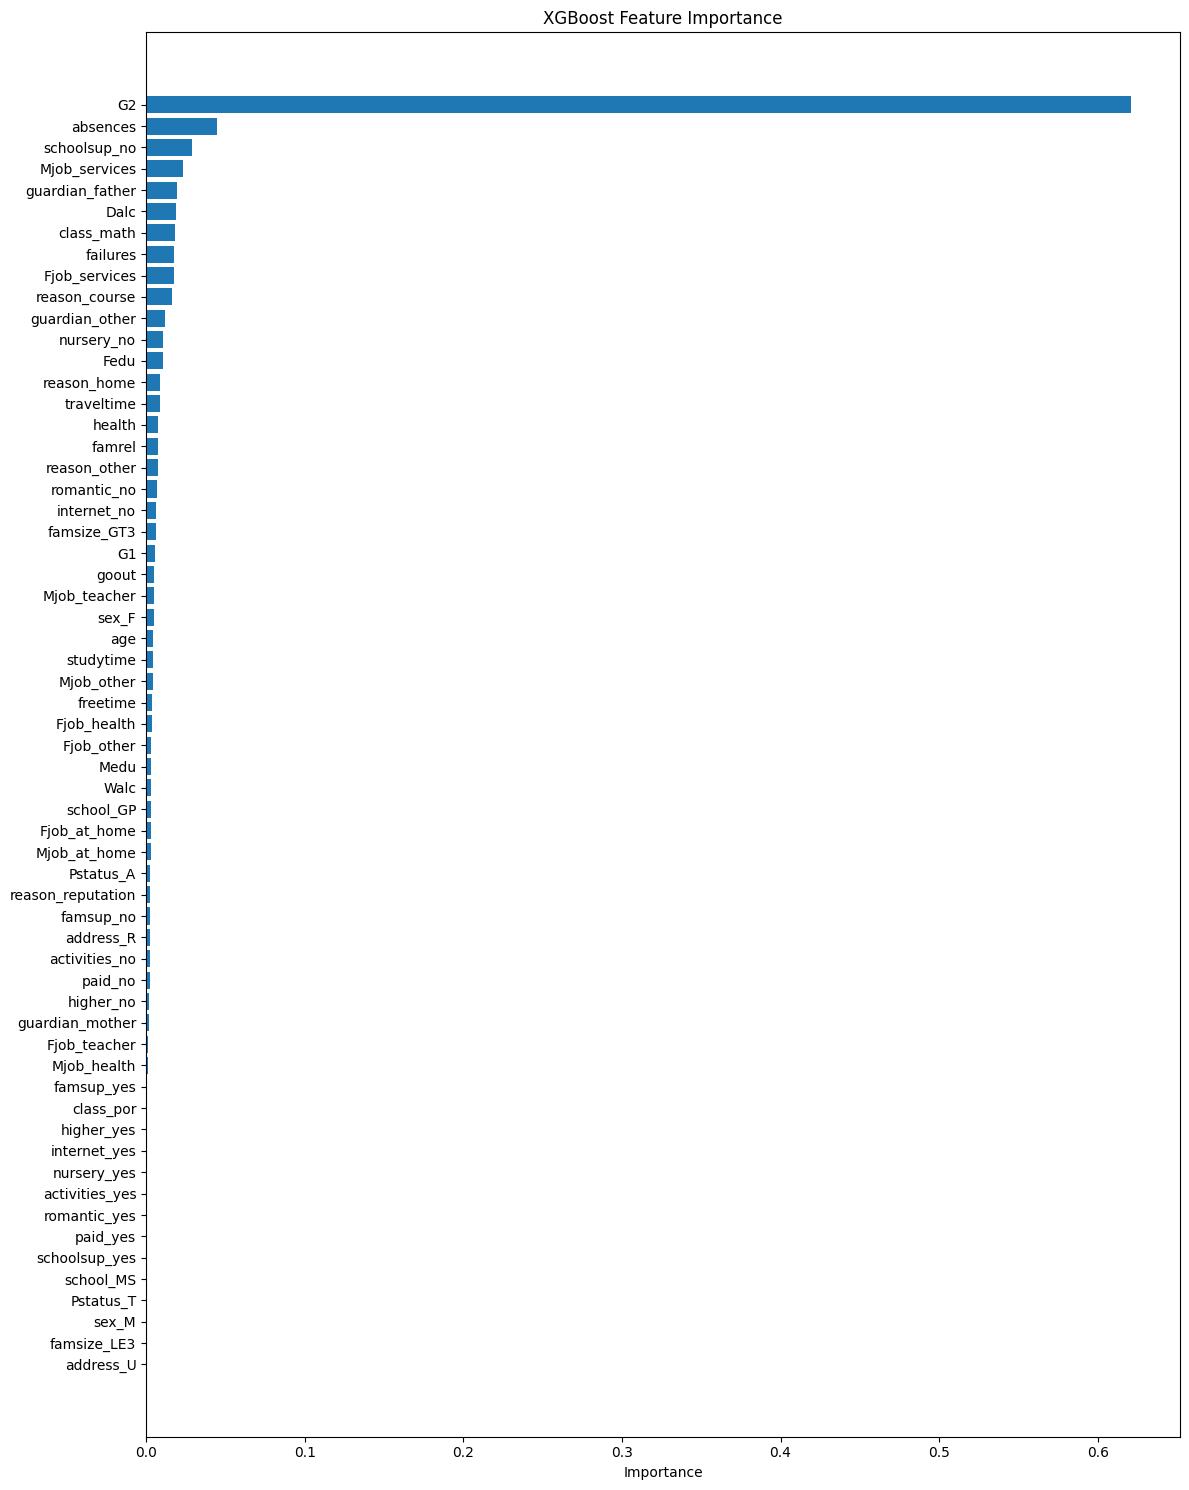

In [4]:
import pandas as pd
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 读取清洗后的完整数据
df = pd.read_csv("data/student_combined_cleaned.csv")

# 特征与目标
X = df.drop(columns=["G3"])
y = df["G3"]
X = pd.get_dummies(X)

# 使用同样的划分方式获取 30% 评估集
_, X_eval, _, y_eval = train_test_split(X, y, test_size=0.3, random_state=42)
X_eval = X_eval.reindex(columns=X.columns, fill_value=0)

# 保存评估集数据
eval_df = pd.concat([X_eval, y_eval], axis=1)
eval_df.to_csv("E:/TPU_Work/jidian_shujufenxi/tpu_8EM41_ML_course/10/data/raw/xgboost_eval_data_full.csv", index=False)

# 加载模型
model = xgb.XGBRegressor()
model.load_model("E:/TPU_Work/jidian_shujufenxi/tpu_8EM41_ML_course/models/xgboost_model_full.json")

# 模型评估
y_pred = model.predict(X_eval)
mse = mean_squared_error(y_eval, y_pred)
r2 = r2_score(y_eval, y_pred)

print("XGBoost 评估结果：")
print("MSE:", mse)
print("R² :", r2)

# 特征重要性图
importances = model.feature_importances_
features = X.columns

# 构造 DataFrame 并按重要性排序
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(12, max(6, len(features) * 0.25)))  # 自动拉高图形防止拥挤
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Importance")
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.savefig("E:/TPU_Work/jidian_shujufenxi/tpu_8EM41_ML_course/10/data/raw/xgboost_feature_importance_full.png", dpi=300)
plt.show()